# Mindestanforderungen 2 - Datenexploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_PATH = Path("output_woche1.csv")

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(49123, 170)


,ResponseId,MainBranch,Age,EdLevel,Employment,Country,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,ConvertedCompMonthly,JobSatisfaction
0,1,I am a developer by profession,25-34 years old,Master’s degree,Employed,Ukraine,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,...,Vertex AI,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,5104.666667,10.0
1,2,I am a developer by profession,25-34 years old,Associate degree,Employed,Netherlands,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,...,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,8701.083333,9.0
2,3,I am a developer by profession,35-44 years old,Bachelor’s degree,"Independent contractor, freelancer, or self-em...",Ukraine,None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,...,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,4421.750000,8.0
3,4,I am a developer by profession,35-44 years old,Bachelor’s degree,Employed,Ukraine,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...",...,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,3016.416667,6.0
4,5,I am a developer by profession,35-44 years old,Master’s degree,"Independent contractor, freelancer, or self-em...",Ukraine,"Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,...,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,5000.000000,7.0


In [3]:
so_cols = df.columns[df.columns.str.startswith("SO")]
df = df.drop(columns=so_cols)

print("Dropped SO columns:", len(so_cols))

Dropped SO columns: 23


SO*-Spalten beziehen sich auf StackOverflow-Plattformfunktionen und sind für unsere Recruiting-Fragestellung (Profile, Skills, Präferenzen, Vergütung) nicht relevant.

In [4]:
df_sorted = df.copy()
df_sorted["YearsCode"] = pd.to_numeric(df_sorted["YearsCode"], errors="coerce")

df_sorted = df_sorted.sort_values("YearsCode", ascending=True)
df_sorted[["YearsCode", "Age", "JobSatisfaction", "WorkExp"]].head(20)


,YearsCode,Age,JobSatisfaction,WorkExp
34539,1.0,25-34 years old,NaN,8.0
23857,1.0,45-54 years old,NaN,20.0
23855,1.0,18-24 years old,NaN,NaN
31075,1.0,35-44 years old,NaN,8.0
36899,1.0,35-44 years old,NaN,14.0
40095,1.0,18-24 years old,NaN,NaN
46197,1.0,55-64 years old,NaN,38.0
31045,1.0,25-34 years old,NaN,4.0
31042,1.0,25-34 years old,NaN,NaN
12081,1.0,18-24 years old,NaN,2.0


Sortierung nach YearsCode hilft, Erfahrungsstufen zu vergleichen (Junior → Senior) und später HR-Maßnahmen/Angebote zielgruppenspezifisch abzuleiten.

In [5]:
df_stats = df.copy()
df_stats["YearsCode"] = pd.to_numeric(df_stats["YearsCode"], errors="coerce")

years_code_stats = df_stats["YearsCode"].describe()
median = df_stats["YearsCode"].median()
mode = df_stats["YearsCode"].mode().iloc[0]
iqr = df_stats["YearsCode"].quantile(0.75) - df_stats["YearsCode"].quantile(0.25)

print("Statistische Zusammenfassung - Programmiererfahrung (YearsCode):")
print("----------------------------------------------------")
print(f"Anzahl gültiger Werte: {years_code_stats['count']:.0f}")
print(f"Durchschnitt: {years_code_stats['mean']:.1f} Jahre")
print(f"Median: {median:.1f} Jahre")
print(f"Häufigster Wert (Modus): {mode:.0f} Jahre")
print(f"Standardabweichung: {years_code_stats['std']:.1f} Jahre")
print(f"Minimum: {years_code_stats['min']:.0f} Jahre")
print(f"25%-Quartil: {years_code_stats['25%']:.1f} Jahre")
print(f"75%-Quartil: {years_code_stats['75%']:.1f} Jahre")
print(f"Maximum: {years_code_stats['max']:.0f} Jahre")
print(f"IQR: {iqr:.1f} Jahre")

Statistische Zusammenfassung - Programmiererfahrung (YearsCode):
----------------------------------------------------
Anzahl gültiger Werte: 43000
Durchschnitt: 16.6 Jahre
Median: 14.0 Jahre
Häufigster Wert (Modus): 10 Jahre
Standardabweichung: 11.8 Jahre
Minimum: 1 Jahre
25%-Quartil: 8.0 Jahre
75%-Quartil: 24.0 Jahre
Maximum: 100 Jahre
IQR: 16.0 Jahre


In [6]:
df_grp = df.copy()
df_grp["ConvertedCompYearly"] = pd.to_numeric(df_grp["ConvertedCompYearly"], errors="coerce")
df_grp["JobSatisfaction"] = pd.to_numeric(df_grp["JobSatisfaction"], errors="coerce")

grouped = df_grp.groupby("RemoteWork").agg(
    count=("RemoteWork", "count"),
    salary_median=("ConvertedCompYearly", "median"),
    jobsat_median=("JobSatisfaction", "median")
).sort_values("count", ascending=False)

grouped

,count,salary_median,jobsat_median
RemoteWork,,,
Remote,10924,88718.5,8.0
"Hybrid (some remote, leans heavy to in-person)",6728,72958.0,7.0
In-person,6034,46406.0,7.0
"Hybrid (some in-person, leans heavy to flexibility)",5824,80966.0,8.0
"Your choice (very flexible, you can come in when you want or just as needed)",4237,75410.0,8.0


- RemoteWork ist für Recruiting relevant, da Arbeitsmodelle (Remote/Hybrid/Onsite) stark in Stellenpräferenzen und ggf. in Gehalt/Zufriedenheit variieren können
- `In-Person` hat hier geringsten salary-median; `Remote` schneidet am besten ab

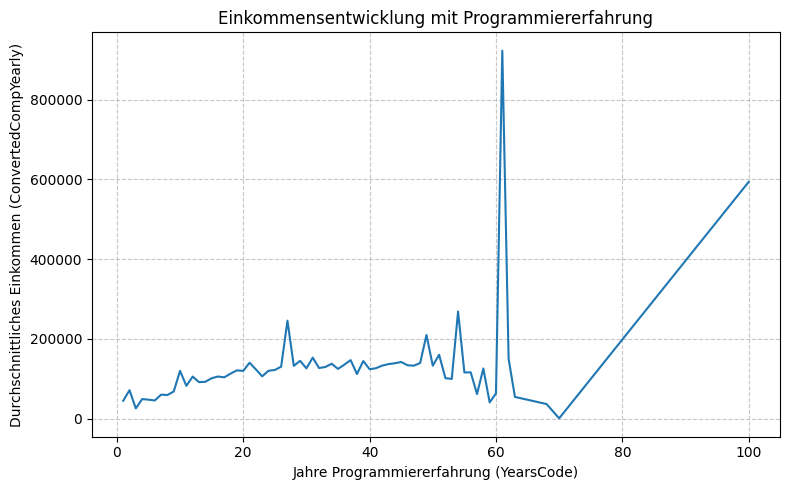

In [7]:
df_line = df.copy()
df_line["YearsCode"] = pd.to_numeric(df_line["YearsCode"], errors="coerce")
df_line["ConvertedCompYearly"] = pd.to_numeric(df_line["ConvertedCompYearly"], errors="coerce")

avg_income = df_line.groupby("YearsCode")["ConvertedCompYearly"].mean().dropna()
avg_income = avg_income.sort_index()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(avg_income.index, avg_income.values)

ax.set_xlabel("Jahre Programmiererfahrung (YearsCode)")
ax.set_ylabel("Durchschnittliches Einkommen (ConvertedCompYearly)")
ax.set_title("Einkommensentwicklung mit Programmiererfahrung")
ax.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()

- Mit zunehmender Erfahrung steigt das durchschnittliche Einkommen tendenziell
- Streuung/Ausreißer sind möglich; Aussage ist aggregiert (Mean) und nicht kausal



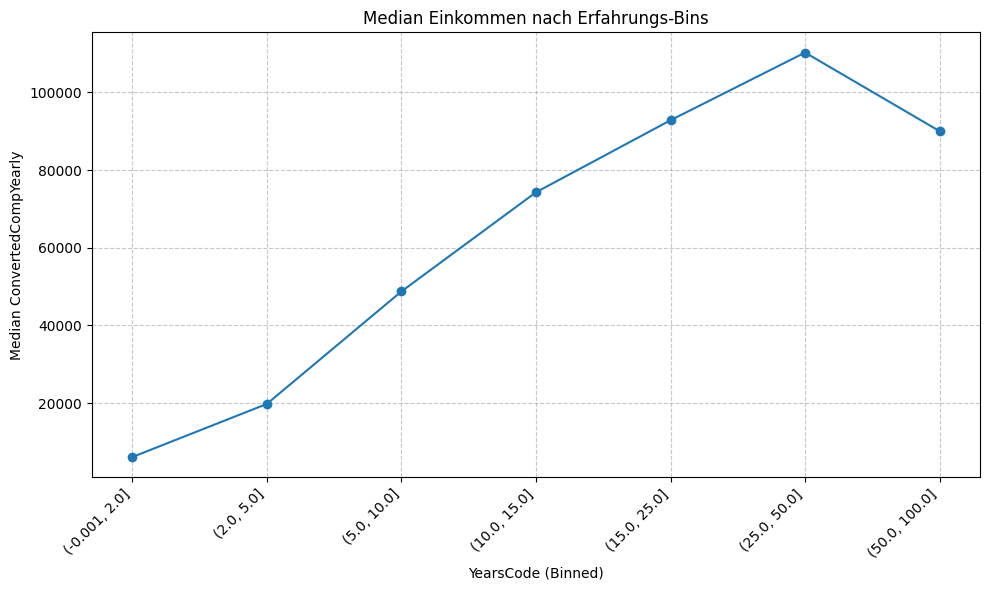

In [8]:
tmp = df[["YearsCode", "ConvertedCompYearly"]].copy()
tmp["YearsCode"] = pd.to_numeric(tmp["YearsCode"], errors="coerce")
tmp["ConvertedCompYearly"] = pd.to_numeric(tmp["ConvertedCompYearly"], errors="coerce")
tmp = tmp.dropna(subset=["YearsCode", "ConvertedCompYearly"])

bins = [0, 2, 5, 10, 15, 25, 50, 100]
tmp["YearsBin"] = pd.cut(tmp["YearsCode"], bins=bins, include_lowest=True)

med_income = tmp.groupby("YearsBin", observed=True)["ConvertedCompYearly"].median()

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(med_income.index.astype(str), med_income.values, marker="o")
ax.set_title("Median Einkommen nach Erfahrungs-Bins")
ax.set_xlabel("YearsCode (Binned)")
ax.set_ylabel("Median ConvertedCompYearly")
ax.grid(True, linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

- Median ist robuster gegen Ausreißer als Mean und somit besser geeignet für Gehaltsband-Argumentation
- Erfahrung wirkt als starker Treiber für Vergütung (aggregiert)

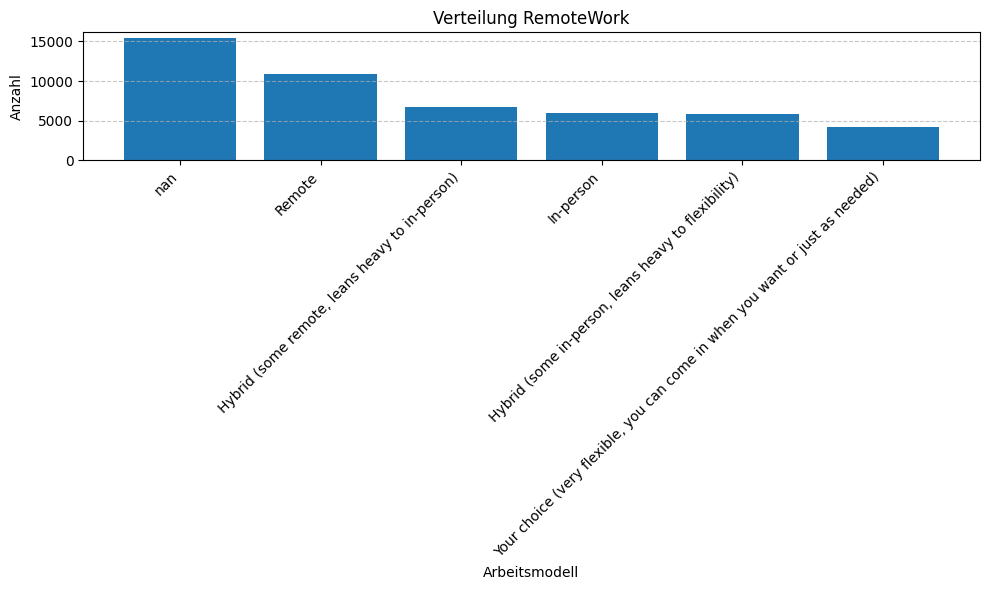

In [9]:
counts = df["RemoteWork"].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(counts.index.astype(str), counts.values)
ax.set_title("Verteilung RemoteWork")
ax.set_xlabel("Arbeitsmodell")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


- Zeigt, welche Arbeitsmodelle im Datensatz dominieren
- Relevant für Recruiting: Stellenanzeigen sollten Arbeitsmodell klar kommunizieren, weil es stark nachgefragt sein kann

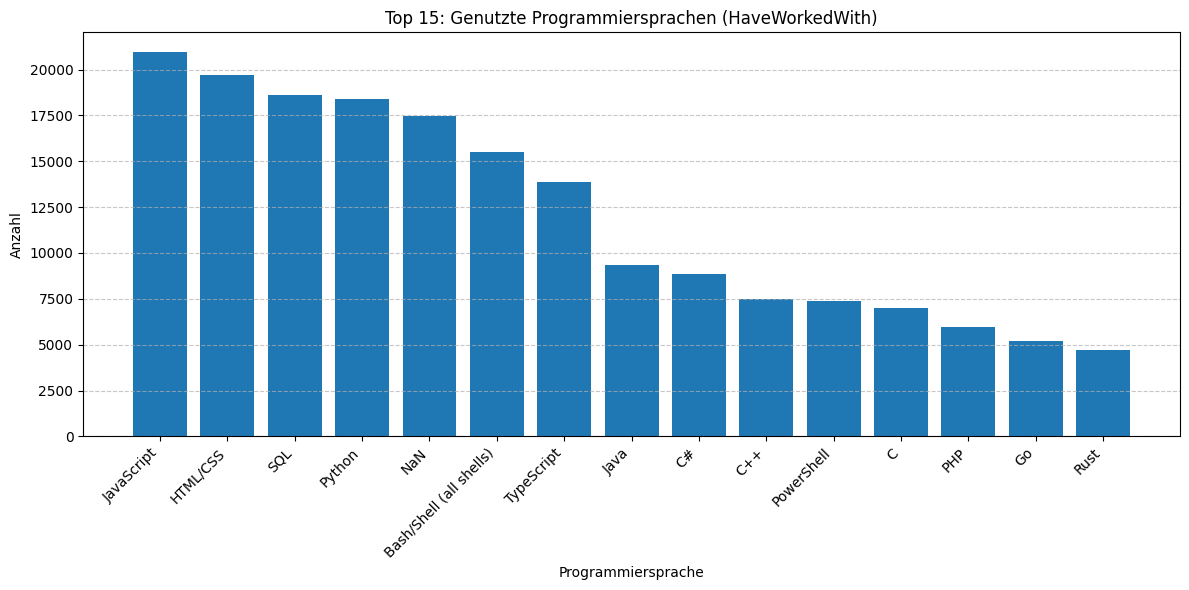

LanguageHaveWorkedWith
JavaScript                 20986
HTML/CSS                   19681
SQL                        18617
Python                     18388
NaN                        17480
Bash/Shell (all shells)    15486
TypeScript                 13852
Java                        9344
C#                          8845
C++                         7479
PowerShell                  7366
C                           6979
PHP                         5990
Go                          5213
Rust                        4717
Name: count, dtype: int64

In [10]:
lang_series = df["LanguageHaveWorkedWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Genutzte Programmiersprachen (HaveWorkedWith)")
ax.set_xlabel("Programmiersprache")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

lang_counts

- Zeigt dominante Skill-Stacks im Markt → hilft beim Formulieren von Must-Have/Nice-to-Have Skills
- Long-Tail sichtbar: viele Nischensprachen, die eher rollen-/domänenspezifisch sind

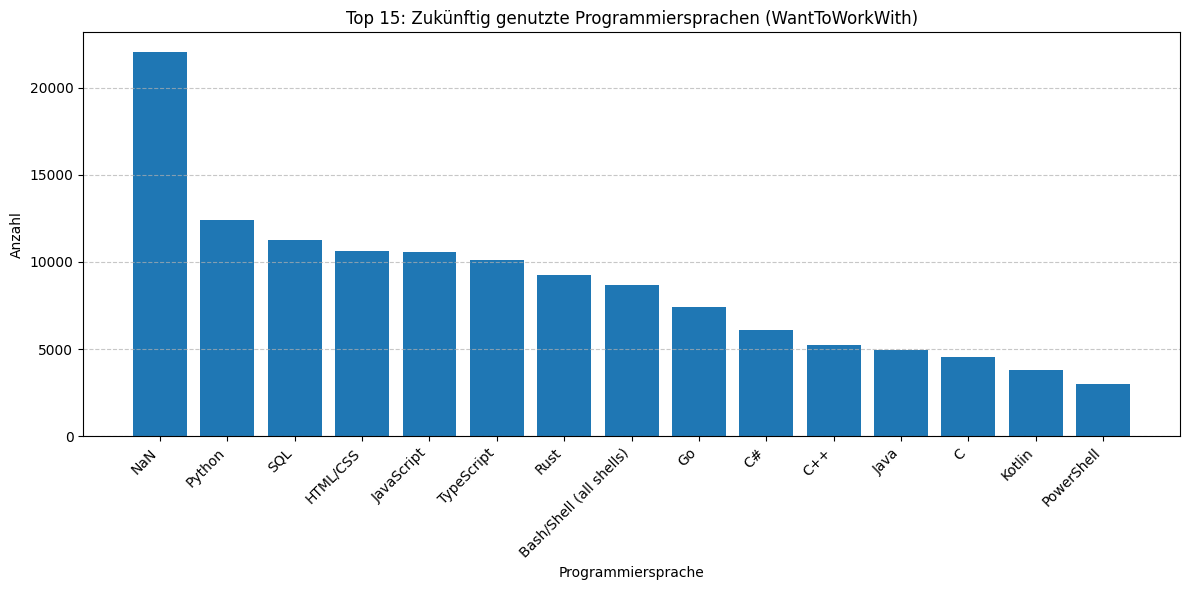

LanguageWantToWorkWith
NaN                        22069
Python                     12408
SQL                        11250
HTML/CSS                   10654
JavaScript                 10574
TypeScript                 10093
Rust                        9250
Bash/Shell (all shells)     8654
Go                          7407
C#                          6114
C++                         5239
Java                        4975
C                           4543
Kotlin                      3777
PowerShell                  3014
Name: count, dtype: int64

In [11]:
lang_series = df["LanguageWantToWorkWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Zukünftig genutzte Programmiersprachen (WantToWorkWith)")
ax.set_xlabel("Programmiersprache")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

lang_counts

- Zeigt Tech-Trends/Präferenzen → hilfreich für Tech-Branding und Zukunfts-Stacks
- Gap Have vs Want kann auf Upskilling-Interesse hinweisen

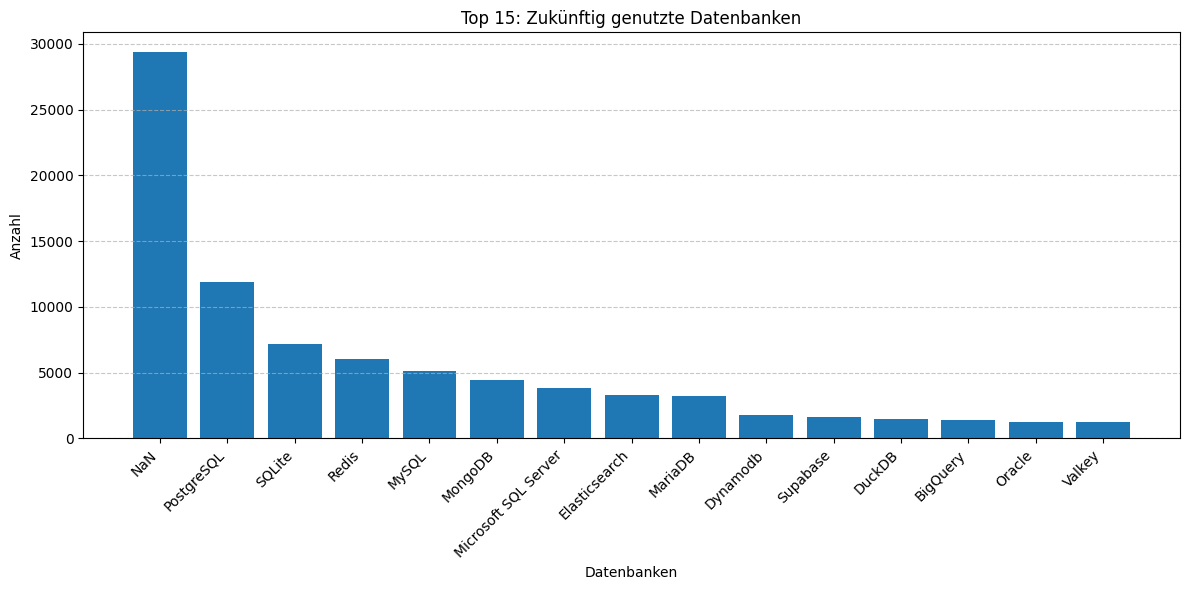

DatabaseWantToWorkWith
NaN                     29405
PostgreSQL              11855
SQLite                   7180
Redis                    6010
MySQL                    5114
MongoDB                  4418
Microsoft SQL Server     3850
Elasticsearch            3284
MariaDB                  3237
Dynamodb                 1740
Supabase                 1619
DuckDB                   1435
BigQuery                 1371
Oracle                   1259
Valkey                   1240
Name: count, dtype: int64

In [12]:
lang_series = df["DatabaseWantToWorkWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Zukünftig genutzte Datenbanken")
ax.set_xlabel("Datenbanken")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

lang_counts

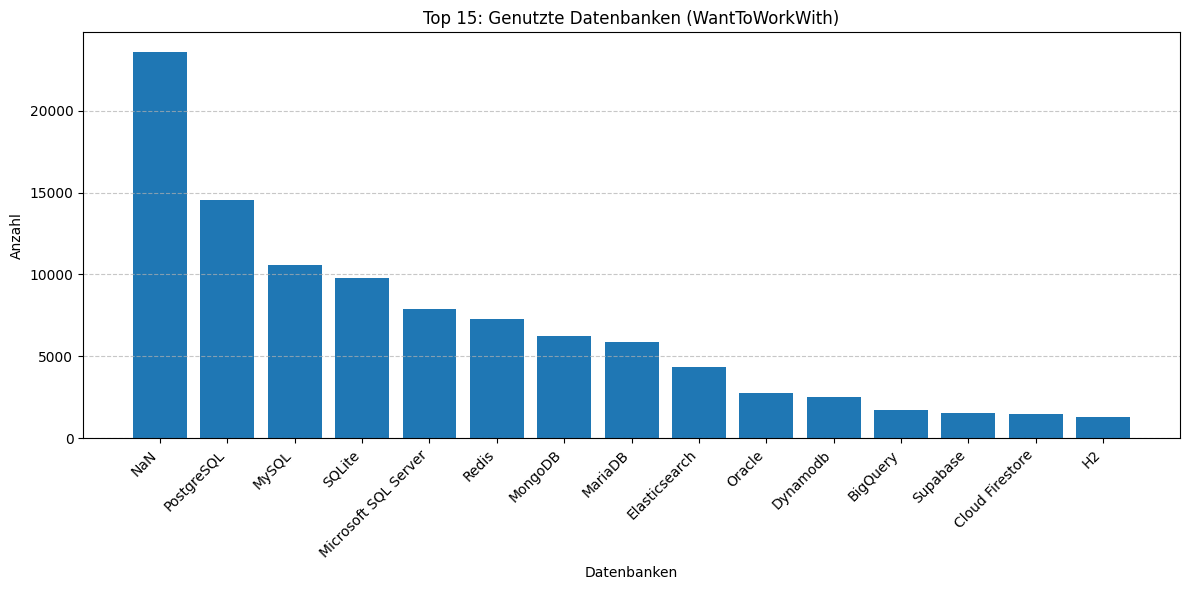

DatabaseHaveWorkedWith
NaN                     23595
PostgreSQL              14516
MySQL                   10568
SQLite                   9787
Microsoft SQL Server     7866
Redis                    7310
MongoDB                  6265
MariaDB                  5857
Elasticsearch            4343
Oracle                   2761
Dynamodb                 2548
BigQuery                 1705
Supabase                 1556
Cloud Firestore          1493
H2                       1303
Name: count, dtype: int64

In [13]:
lang_series = df["DatabaseHaveWorkedWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Genutzte Datenbanken (WantToWorkWith)")
ax.set_xlabel("Datenbanken")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

lang_counts

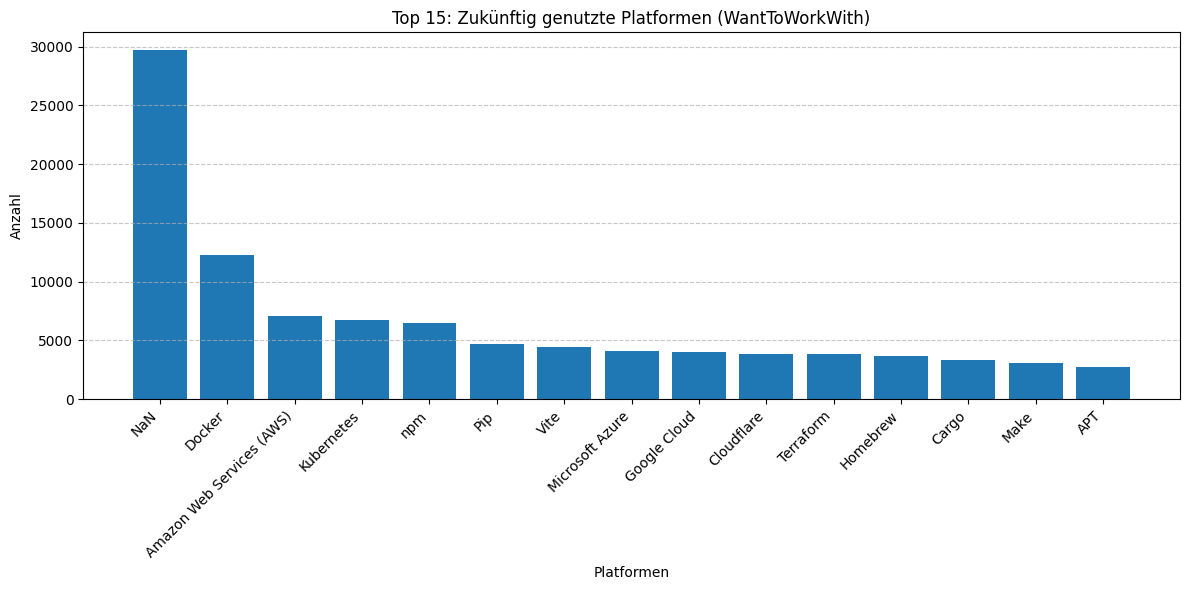

PlatformWantToWorkWith
NaN                          29727
Docker                       12232
Amazon Web Services (AWS)     7097
Kubernetes                    6763
npm                           6499
Pip                           4737
Vite                          4453
Microsoft Azure               4087
Google Cloud                  3991
Cloudflare                    3841
Terraform                     3811
Homebrew                      3697
Cargo                         3354
Make                          3044
APT                           2780
Name: count, dtype: int64

In [14]:
lang_series = df["PlatformWantToWorkWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Zukünftig genutzte Platformen (WantToWorkWith)")
ax.set_xlabel("Platformen")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
lang_counts

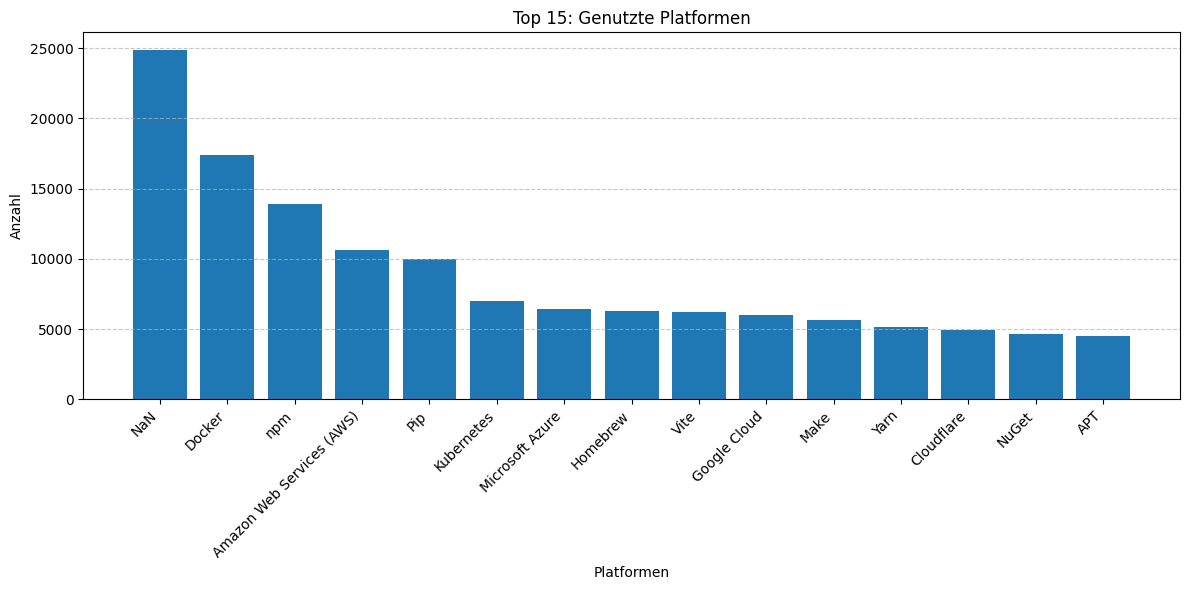

PlatformHaveWorkedWith
NaN                          24889
Docker                       17396
npm                          13892
Amazon Web Services (AWS)    10605
Pip                          10015
Kubernetes                    6986
Microsoft Azure               6442
Homebrew                      6282
Vite                          6209
Google Cloud                  6013
Make                          5674
Yarn                          5174
Cloudflare                    4918
NuGet                         4632
APT                           4512
Name: count, dtype: int64

In [15]:
lang_series = df["PlatformHaveWorkedWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Genutzte Platformen")
ax.set_xlabel("Platformen")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
lang_counts

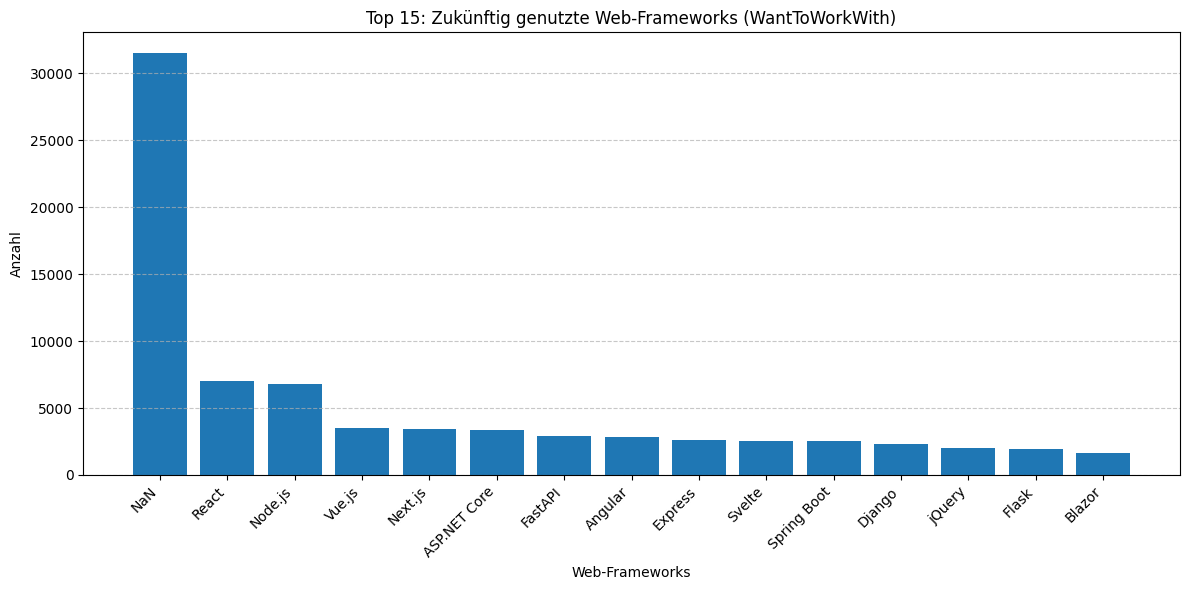

WebframeWantToWorkWith
NaN             31500
React            7018
Node.js          6803
Vue.js           3514
Next.js          3423
ASP.NET Core     3359
FastAPI          2918
Angular          2858
Express          2620
Svelte           2539
Spring Boot      2509
Django           2302
jQuery           2015
Flask            1955
Blazor           1617
Name: count, dtype: int64

In [16]:
lang_series = df["WebframeWantToWorkWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Zukünftig genutzte Web-Frameworks (WantToWorkWith)")
ax.set_xlabel("Web-Frameworks")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

lang_counts

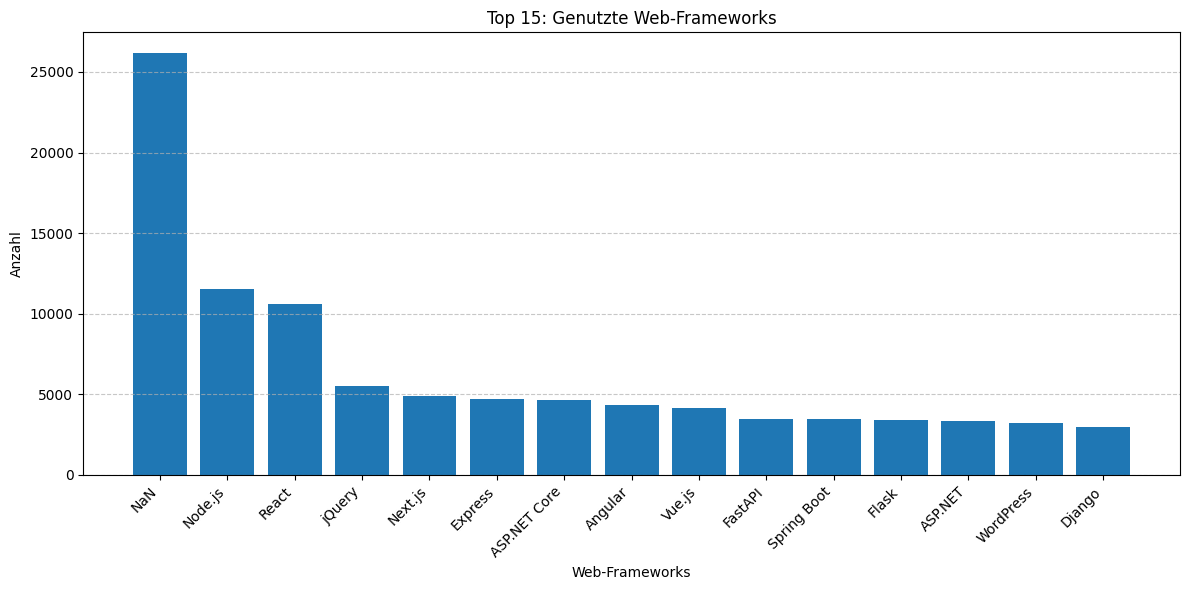

WebframeHaveWorkedWith
NaN             26153
Node.js         11534
React           10581
jQuery           5537
Next.js          4924
Express          4706
ASP.NET Core     4659
Angular          4315
Vue.js           4161
FastAPI          3501
Spring Boot      3475
Flask            3402
ASP.NET          3356
WordPress        3223
Django           2977
Name: count, dtype: int64

In [17]:
lang_series = df["WebframeHaveWorkedWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Genutzte Web-Frameworks")
ax.set_xlabel("Web-Frameworks")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
lang_counts

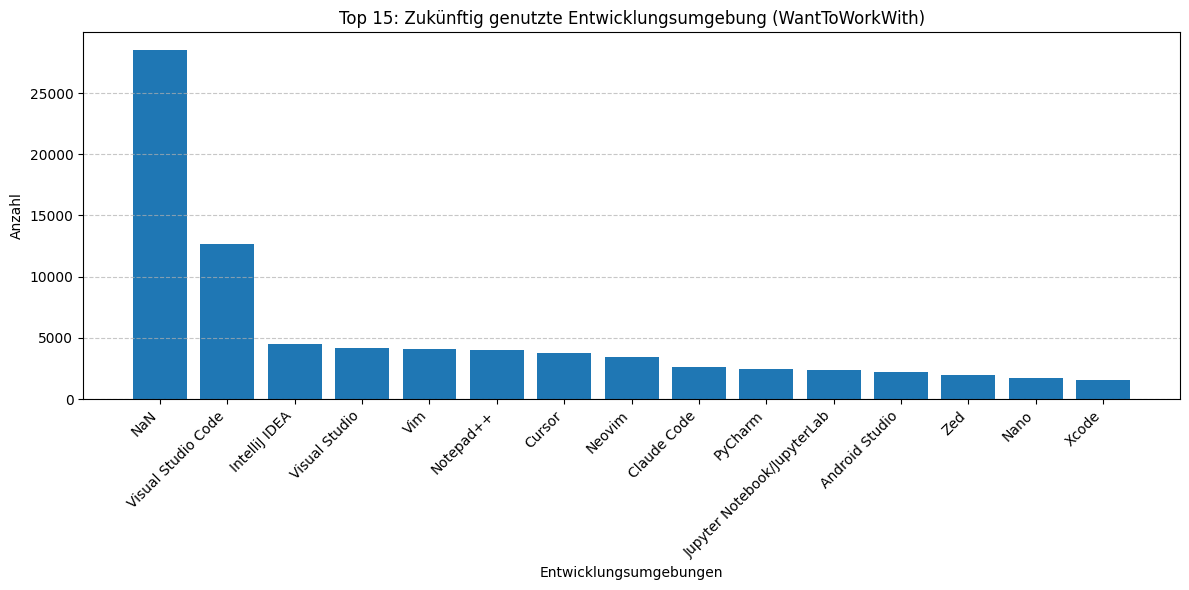

DevEnvsWantToWorkWith
NaN                            28531
Visual Studio Code             12710
IntelliJ IDEA                   4543
Visual Studio                   4145
Vim                             4073
Notepad++                       4025
Cursor                          3783
Neovim                          3440
Claude Code                     2641
PyCharm                         2465
Jupyter Notebook/JupyterLab     2394
Android Studio                  2252
Zed                             1939
Nano                            1718
Xcode                           1561
Name: count, dtype: int64

In [18]:
lang_series = df["DevEnvsWantToWorkWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Zukünftig genutzte Entwicklungsumgebung (WantToWorkWith)")
ax.set_xlabel("Entwicklungsumgebungen")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
lang_counts

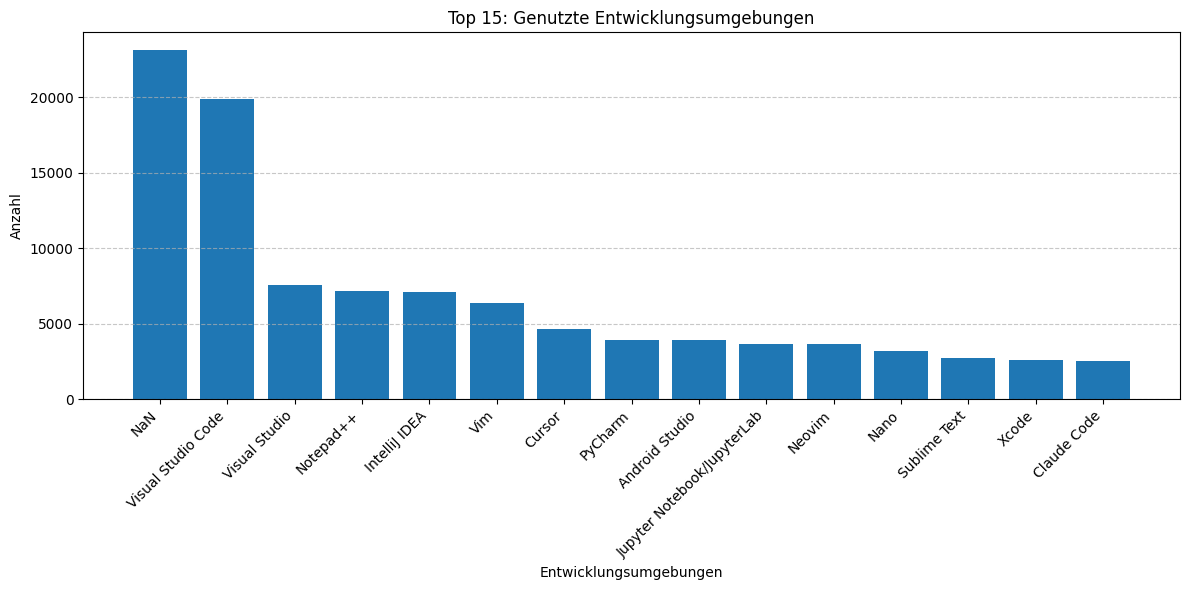

DevEnvsHaveWorkedWith
NaN                            23129
Visual Studio Code             19852
Visual Studio                   7583
Notepad++                       7170
IntelliJ IDEA                   7095
Vim                             6348
Cursor                          4671
PyCharm                         3935
Android Studio                  3914
Jupyter Notebook/JupyterLab     3678
Neovim                          3659
Nano                            3201
Sublime Text                    2734
Xcode                           2619
Claude Code                     2534
Name: count, dtype: int64

In [19]:
lang_series = df["DevEnvsHaveWorkedWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Genutzte Entwicklungsumgebungen")
ax.set_xlabel("Entwicklungsumgebungen")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
lang_counts

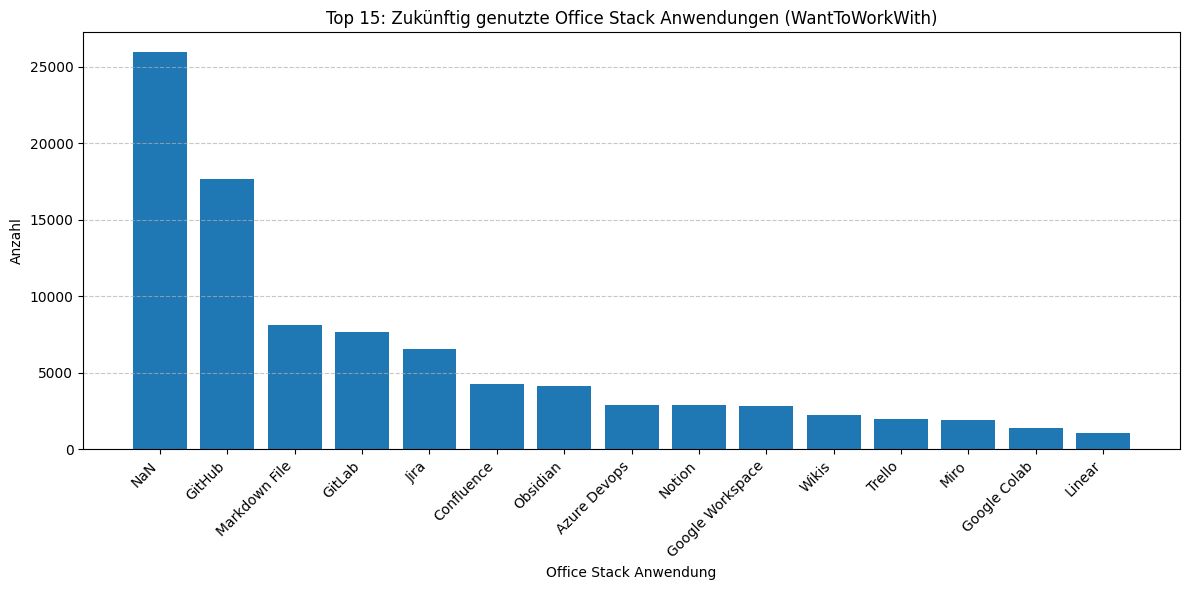

OfficeStackAsyncWantToWorkWith
NaN                 25940
GitHub              17682
Markdown File        8088
GitLab               7634
Jira                 6557
Confluence           4262
Obsidian             4111
Azure Devops         2922
Notion               2896
Google Workspace     2801
Wikis                2230
Trello               1997
Miro                 1893
Google Colab         1411
Linear               1062
Name: count, dtype: int64

In [20]:
lang_series = df["OfficeStackAsyncWantToWorkWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Zukünftig genutzte Office Stack Anwendungen (WantToWorkWith)")
ax.set_xlabel("Office Stack Anwendung")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
lang_counts

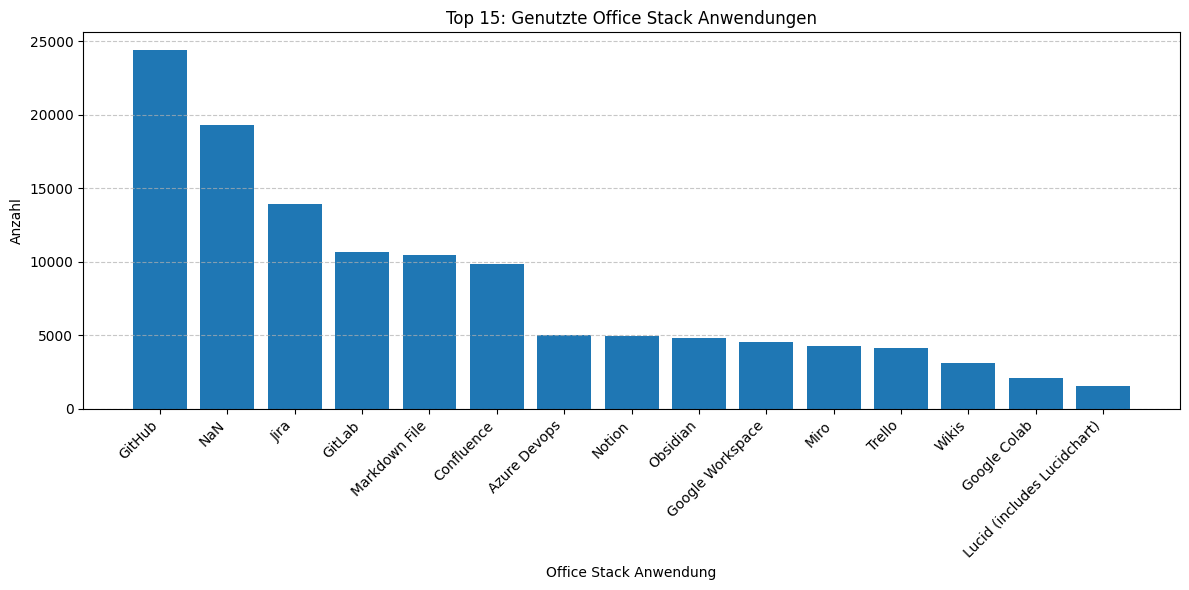

OfficeStackAsyncHaveWorkedWith
GitHub                         24395
NaN                            19293
Jira                           13958
GitLab                         10707
Markdown File                  10456
Confluence                      9854
Azure Devops                    5002
Notion                          4959
Obsidian                        4844
Google Workspace                4560
Miro                            4295
Trello                          4126
Wikis                           3115
Google Colab                    2109
Lucid (includes Lucidchart)     1579
Name: count, dtype: int64

In [21]:
lang_series = df["OfficeStackAsyncHaveWorkedWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Genutzte Office Stack Anwendungen")
ax.set_xlabel("Office Stack Anwendung")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
lang_counts

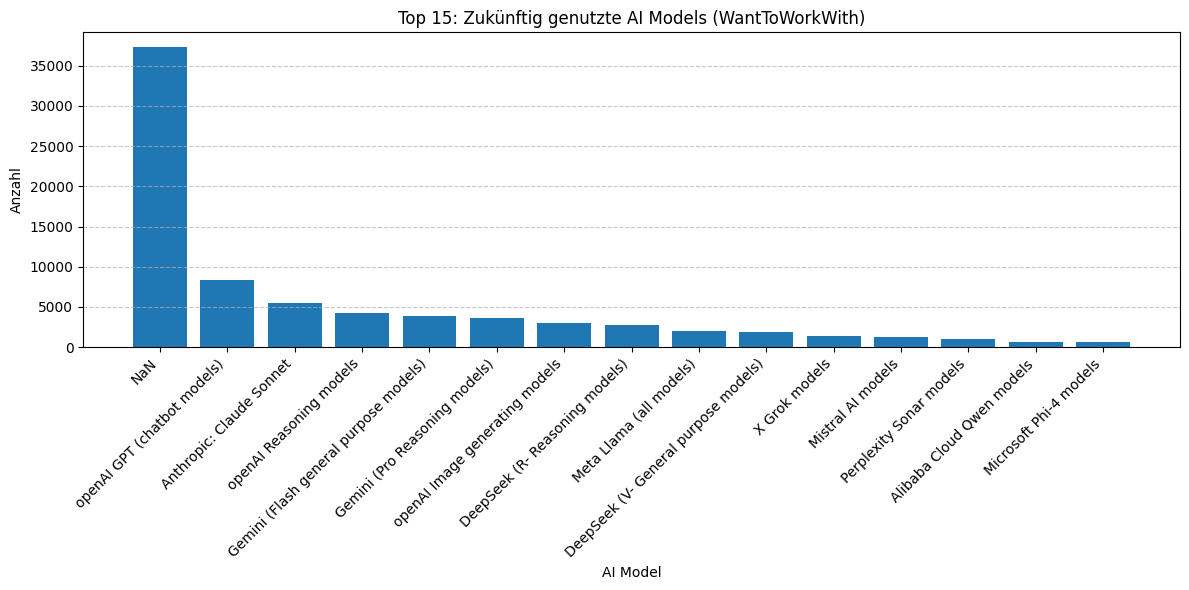

AIModelsWantToWorkWith
NaN                                      37291
openAI GPT (chatbot models)               8321
Anthropic: Claude Sonnet                  5423
openAI Reasoning models                   4209
Gemini (Flash general purpose models)     3863
Gemini (Pro Reasoning models)             3665
openAI Image generating models            3028
DeepSeek (R- Reasoning models)            2749
Meta Llama (all models)                   2003
DeepSeek (V- General purpose models)      1832
X Grok models                             1428
Mistral AI models                         1287
Perplexity Sonar models                   1010
Alibaba Cloud Qwen models                  669
Microsoft Phi-4 models                     627
Name: count, dtype: int64

In [22]:
lang_series = df["AIModelsWantToWorkWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Zukünftig genutzte AI Models (WantToWorkWith)")
ax.set_xlabel("AI Model")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
lang_counts

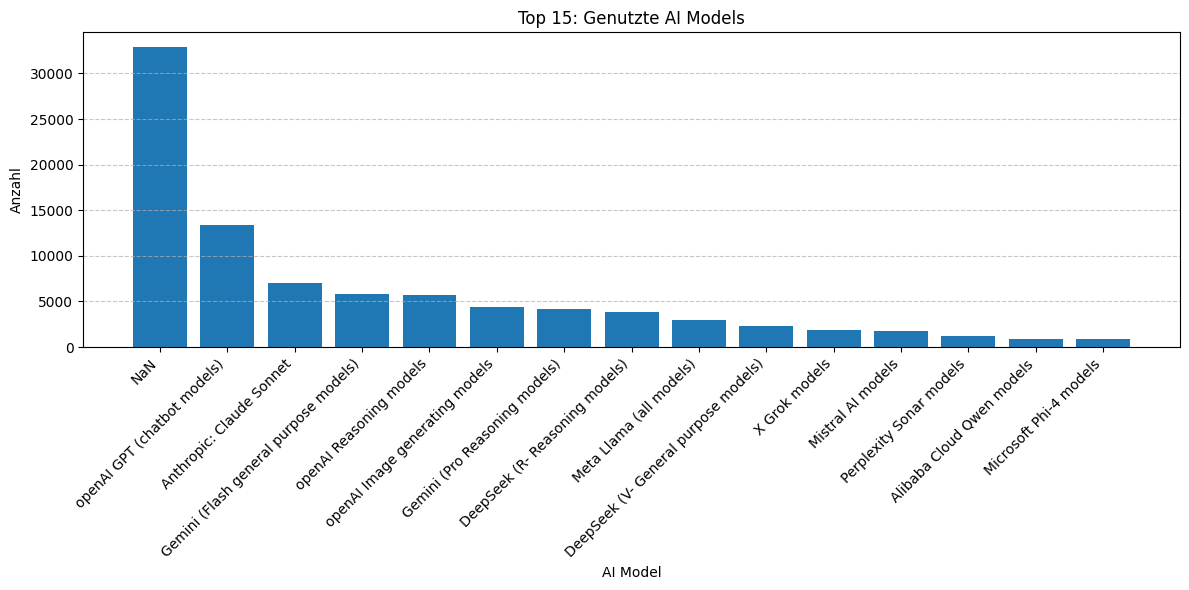

AIModelsHaveWorkedWith
NaN                                      32862
openAI GPT (chatbot models)              13408
Anthropic: Claude Sonnet                  7055
Gemini (Flash general purpose models)     5816
openAI Reasoning models                   5706
openAI Image generating models            4388
Gemini (Pro Reasoning models)             4213
DeepSeek (R- Reasoning models)            3845
Meta Llama (all models)                   2937
DeepSeek (V- General purpose models)      2363
X Grok models                             1836
Mistral AI models                         1710
Perplexity Sonar models                   1248
Alibaba Cloud Qwen models                  864
Microsoft Phi-4 models                     831
Name: count, dtype: int64

In [23]:
lang_series = df["AIModelsHaveWorkedWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Genutzte AI Models")
ax.set_xlabel("AI Model")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
lang_counts

- anhand der jeweiligen Top 15 sind schon Präferenzen der Entwickler zu sehen
- leider auch viele `NaN`-Werte im Datensatz vorhanden, macht spätere Auswertungen schwieriger

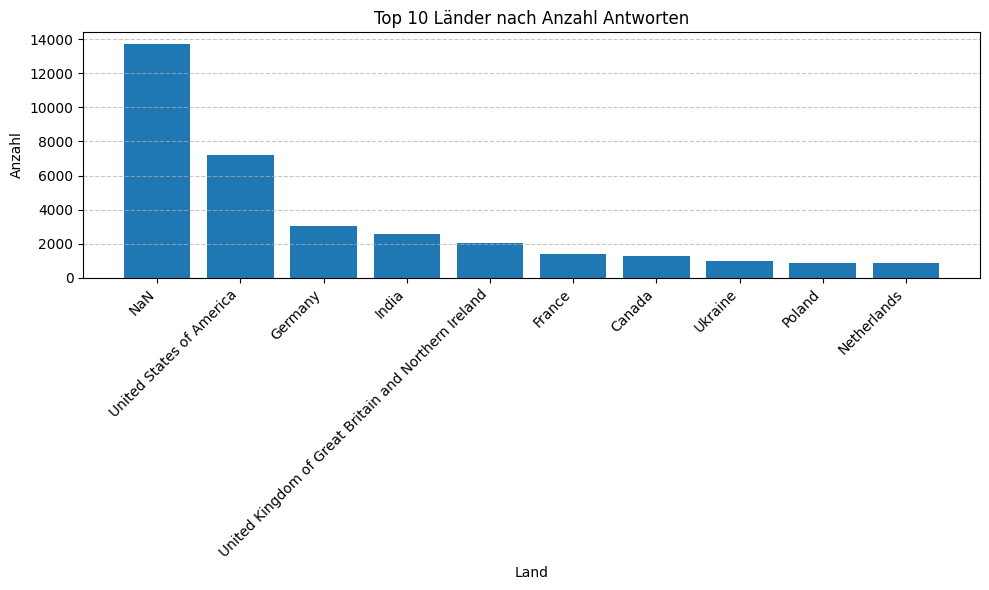

In [24]:
country_counts = df["Country"].fillna("NaN").value_counts().head(10)

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(country_counts.index.astype(str), country_counts.values)
ax.set_title("Top 10 Länder nach Anzahl Antworten")
ax.set_xlabel("Land")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

- Hilft zu verstehen, welche Regionen im Datensatz stark vertreten sind (Bias/Interpretationsgrenze)
- Relevant für Recruiting: regionale Segmentierung und Gehalts-/Remote-Vergleiche

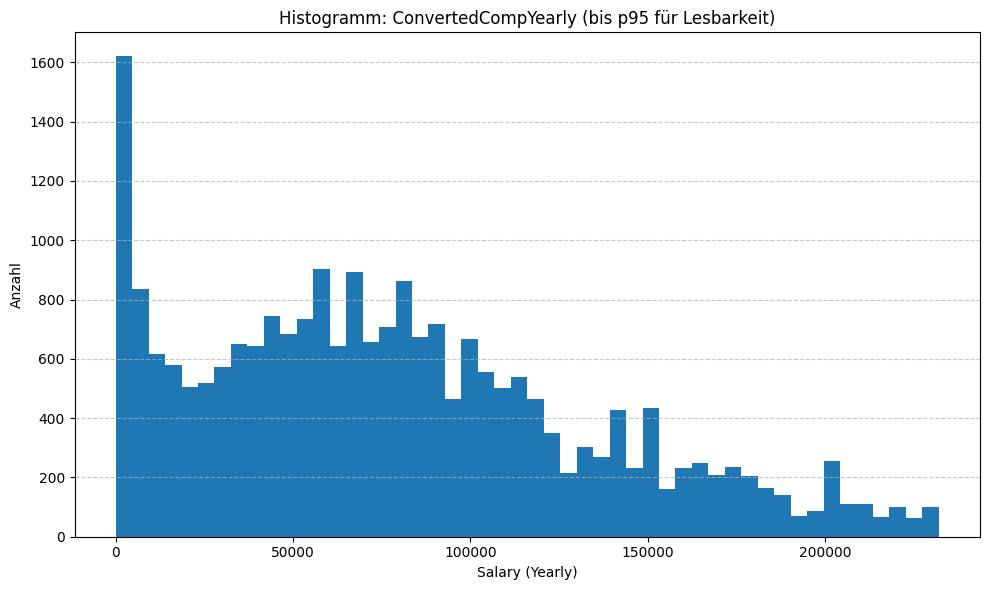

In [25]:
sal = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce").dropna()

p95 = sal.quantile(0.95)
sal_cut = sal[sal <= p95]

fig, ax = plt.subplots(figsize=(10,6))
ax.hist(sal_cut, bins=50)
ax.set_title("Histogramm: ConvertedCompYearly (bis p95 für Lesbarkeit)")
ax.set_xlabel("Salary (Yearly)")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


- beim Gehalt haben wir ebenfalls die oberen 5% herausgenommen um eine bessere Lesbarkeit des Grapen gewährleisten zu können
- man sieht, dass niedrigere Gehälter öfter vorkommen als höhere

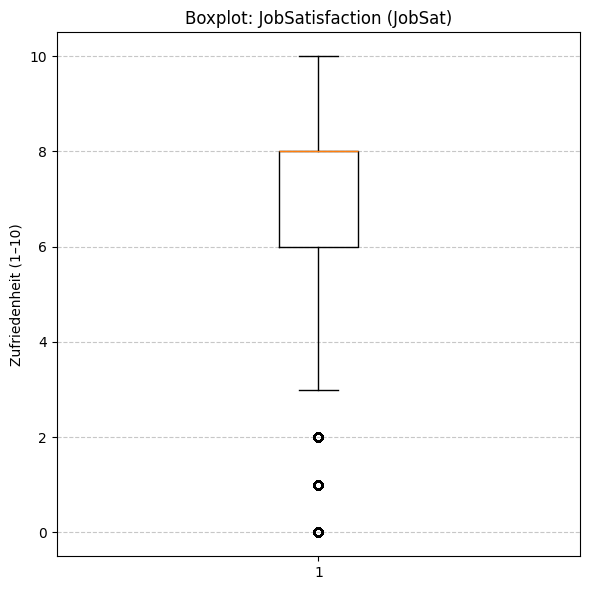

Median JobSatisfaction: 8.0


In [26]:
jobsat = pd.to_numeric(df["JobSatisfaction"], errors="coerce").dropna()

fig, ax = plt.subplots(figsize=(6,6))
ax.boxplot(jobsat, vert=True)
ax.set_title("Boxplot: JobSatisfaction (JobSat)")
ax.set_ylabel("Zufriedenheit (1–10)")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

print("Median JobSatisfaction:", float(np.median(jobsat)))


- Median zeigt die typische Zufriedenheit, Box die Streuung (IQR)
- Ausreißer nach unten können auf unzufriedene Subgruppen hindeuten

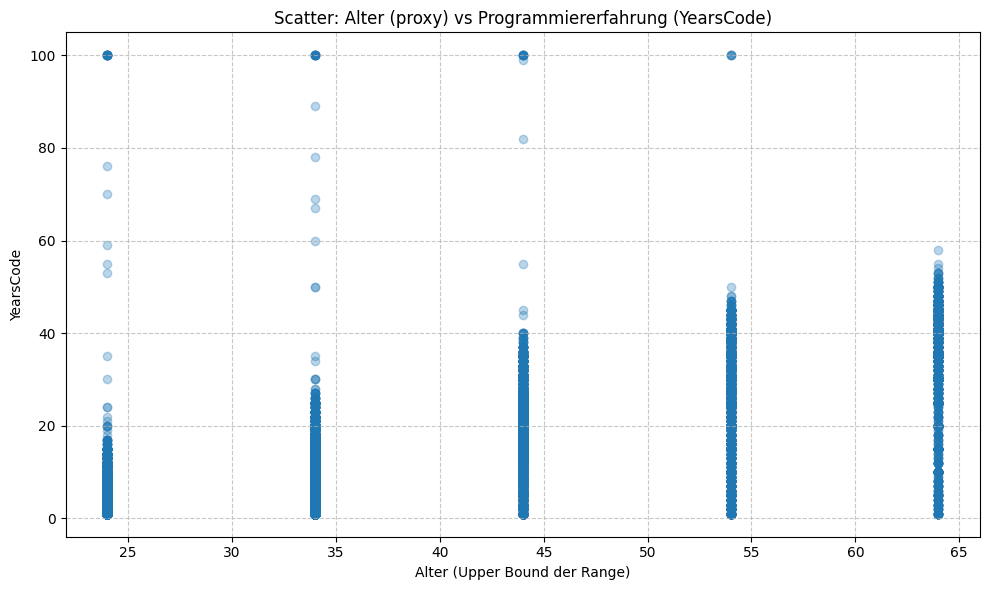

Korrelationskoeffizient: 0.746


In [27]:
scatter_df = df[["Age", "YearsCode"]].copy()

# Upper bound aus Altersrange extrahieren (z.B. "25-34 years old" -> 34)
age_upper = scatter_df["Age"].astype(str).str.extract(r"(\d+)-(\d+)")[1]
scatter_df["Age_Numeric"] = pd.to_numeric(age_upper, errors="coerce")
scatter_df["YearsCode"] = pd.to_numeric(scatter_df["YearsCode"], errors="coerce")

scatter_df = scatter_df.dropna(subset=["Age_Numeric", "YearsCode"])

fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(scatter_df["Age_Numeric"], scatter_df["YearsCode"], alpha=0.3)
ax.set_title("Scatter: Alter (proxy) vs Programmiererfahrung (YearsCode)")
ax.set_xlabel("Alter (Upper Bound der Range)")
ax.set_ylabel("YearsCode")
ax.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

corr = np.corrcoef(scatter_df["Age_Numeric"], scatter_df["YearsCode"])[0, 1]
print("Korrelationskoeffizient:", round(float(corr), 3))


- Positiver Zusammenhang: ältere Personen haben im Schnitt mehr Programmiererfahrung
- Unplausible Punkte (`YearsCode` > `Age`) deuten auf Datenbereinigungsbedarf hin

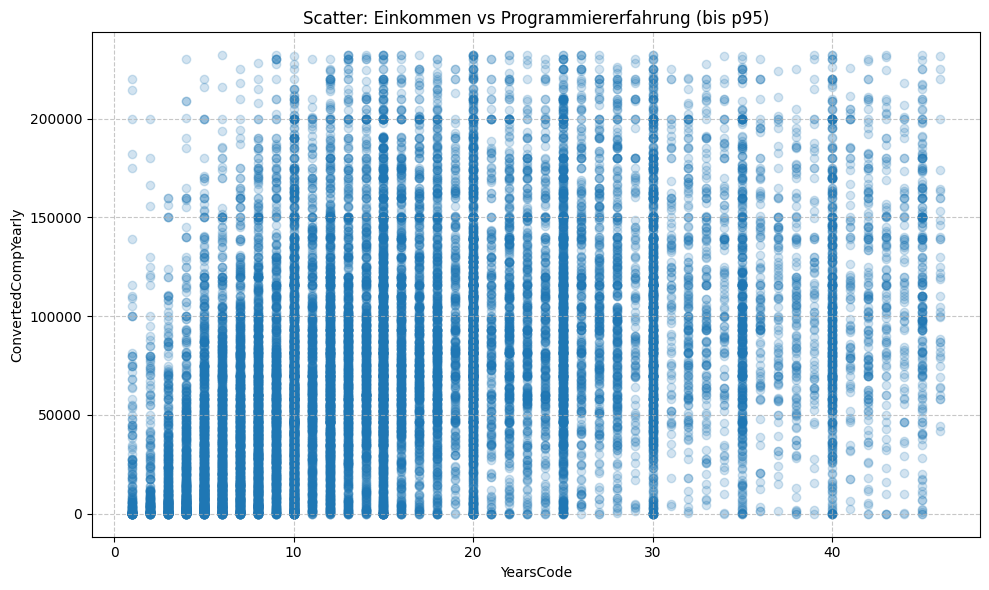

In [28]:
tmp = df[["YearsCode", "ConvertedCompYearly"]].copy()
tmp["YearsCode"] = pd.to_numeric(tmp["YearsCode"], errors="coerce")
tmp["ConvertedCompYearly"] = pd.to_numeric(tmp["ConvertedCompYearly"], errors="coerce")
tmp = tmp.dropna(subset=["YearsCode", "ConvertedCompYearly"])

p95_salary = tmp["ConvertedCompYearly"].quantile(0.95)
p95_years  = tmp["YearsCode"].quantile(0.99)
tmp = tmp[(tmp["ConvertedCompYearly"] <= p95_salary) & (tmp["YearsCode"] <= p95_years)]

fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(tmp["YearsCode"], tmp["ConvertedCompYearly"], alpha=0.2)
ax.set_title("Scatter: Einkommen vs Programmiererfahrung (bis p95)")
ax.set_xlabel("YearsCode")
ax.set_ylabel("ConvertedCompYearly")
ax.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


- Mit steigender Programmiererfahrung steigt das Einkommen tendenziell; die Punktwolke zeigt aber große Streuung
- Für bessere Lesbarkeit wurden extreme Ausreißer (obere 1% bzw. 5%) entfernt, da vereinzelt "Quatsch-Werte" vorhanden waren (z.B. Codeerfahrung = 100 Jahre)


In [29]:
df.to_csv("./output_woche2.csv", index=False)

print("Gespeichert:", df.shape, "-> Abgaben/output_woche2.csv")


Gespeichert: (49123, 147) -> Abgaben/output_woche2.csv
